In [6]:
import os

# ============================================================
# Detect whether the notebook is running in Google Colab
# ============================================================

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False


# ============================================================
# Google Colab
# ============================================================

if IN_COLAB:

    REPO_URL = "https://github.com/Nrrahat/AI_ML_Final_Project.git"
    REPO_NAME = "AI_ML_Final_Project"

    REPO_DIR = f"/content/{REPO_NAME}"

    # Clone repository only if it does not already exist
    if not os.path.exists(REPO_DIR):
        !git clone {REPO_URL}

    DATASET_DIR = os.path.join(
        REPO_DIR,
        "dataset"
    )

    MODEL_DIR = os.path.join(
        REPO_DIR,
        "model"
    )


# ============================================================
# VS Code / Local Computer
# ============================================================

else:

    # Notebook is inside AI_ML_Final_Project
    REPO_DIR = os.getcwd()

    DATASET_DIR = os.path.join(
        REPO_DIR,
        "dataset"
    )

    MODEL_DIR = os.path.join(
        REPO_DIR,
        "model"
    )


# ============================================================
# Create model directory if necessary
# ============================================================

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)


# ============================================================
# Display paths
# ============================================================

print("Running in Colab:", IN_COLAB)
print("Repository:", REPO_DIR)
print("Dataset:", DATASET_DIR)
print("Model:", MODEL_DIR)

print("\nDataset exists:", os.path.exists(DATASET_DIR))

if os.path.exists(DATASET_DIR):
    print("Files in dataset:")
    print(os.listdir(DATASET_DIR))

Running in Colab: False
Repository: e:\sabbir_vai\AI_ML_Final_Project
Dataset: e:\sabbir_vai\AI_ML_Final_Project\dataset
Model: e:\sabbir_vai\AI_ML_Final_Project\model

Dataset exists: True
Files in dataset:
['ankle_boot.jpg', 'bag.jpg', 'coat.jpg', 'dress.jpg', 'pullover.jpg', 'sandal.jpg', 'shirt.jpg', 'sneaker.jpg', 'trouser.jpg', 'tshirt.jpg']


In [7]:
import os
import random

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from PIL import Image

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [8]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [9]:
BATCH_SIZE = 64
EPOCHS = 5

MODEL_PATH = os.path.join(
    MODEL_DIR,
    "fashion_mnist_cnn.keras"
)


# Automatically decide whether to train
if os.path.exists(MODEL_PATH):

    TRAIN_MODEL = False

    print("Saved model found.")
    print("Training will be skipped.")

else:

    TRAIN_MODEL = True

    print("No saved model found.")
    print("Model will be trained.")


print("Model path:", MODEL_PATH)
print("TRAIN_MODEL:", TRAIN_MODEL)

Saved model found.
Training will be skipped.
Model path: e:\sabbir_vai\AI_ML_Final_Project\model\fashion_mnist_cnn.keras
TRAIN_MODEL: False


In [10]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

In [11]:
custom_images = sorted([
    file
    for file in os.listdir(DATASET_DIR)
    if file.lower().endswith(
        (".jpg", ".jpeg", ".png")
    )
])

print("Number of custom images:", len(custom_images))

for file in custom_images:
    print(file)

Number of custom images: 10
ankle_boot.jpg
bag.jpg
coat.jpg
dress.jpg
pullover.jpg
sandal.jpg
shirt.jpg
sneaker.jpg
trouser.jpg
tshirt.jpg


In [12]:
(x_train, y_train), (x_test, y_test) = (
    keras.datasets.fashion_mnist.load_data()
)

print("Training:", x_train.shape)
print("Test:", x_test.shape)

Training: (60000, 28, 28)
Test: (10000, 28, 28)


In [13]:
mean = 0.2860
std = 0.3530

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(
    x_train,
    axis=-1
)

x_test = np.expand_dims(
    x_test,
    axis=-1
)

x_train = (
    x_train - mean
) / std

x_test = (
    x_test - mean
) / std

print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [14]:
validation_size = 6000

x_val = x_train[-validation_size:]
y_val = y_train[-validation_size:]

x_train_new = x_train[:-validation_size]
y_train_new = y_train[:-validation_size]

print("Training:", x_train_new.shape)
print("Validation:", x_val.shape)
print("Test:", x_test.shape)

Training: (54000, 28, 28, 1)
Validation: (6000, 28, 28, 1)
Test: (10000, 28, 28, 1)


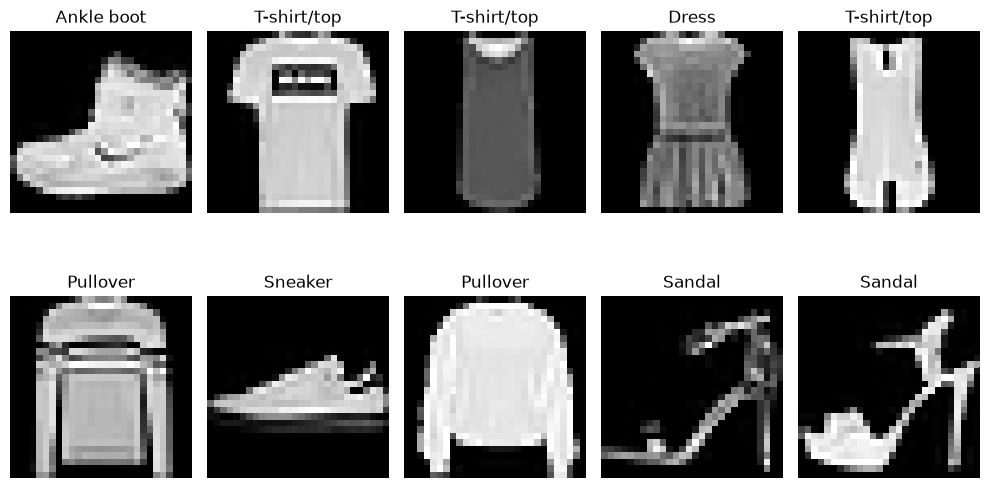

In [15]:
plt.figure(figsize=(10, 6))

for i in range(10):

    image = (
        x_train_new[i] * std
    ) + mean

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        image.squeeze(),
        cmap="gray"
    )

    plt.title(
        class_names[y_train_new[i]]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
def create_cnn_model():

    model = keras.Sequential([

        layers.Input(
            shape=(28, 28, 1)
        ),

        layers.Conv2D(
            32,
            (3, 3),
            padding="same",
            activation="relu"
        ),

        layers.MaxPooling2D(
            (2, 2)
        ),

        layers.Conv2D(
            64,
            (3, 3),
            padding="same",
            activation="relu"
        ),

        layers.MaxPooling2D(
            (2, 2)
        ),

        layers.Flatten(),

        layers.Dense(
            128,
            activation="relu"
        ),

        layers.Dropout(0.5),

        layers.Dense(
            10,
            activation="softmax"
        )
    ])

    return model


model = create_cnn_model()

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

In [18]:
if TRAIN_MODEL:

    print("Training CNN...")

    history = model.fit(

        x_train_new,
        y_train_new,

        validation_data=(
            x_val,
            y_val
        ),

        epochs=EPOCHS,

        batch_size=BATCH_SIZE,

        verbose=1
    )

    model.save(
        MODEL_PATH
    )

    print(
        "\nModel trained and saved:"
    )

    print(MODEL_PATH)

else:

    print(
        "Loading saved model..."
    )

    model = keras.models.load_model(
        MODEL_PATH
    )

    print(
        "Model loaded successfully."
    )

Loading saved model...
Model loaded successfully.


In [19]:
if TRAIN_MODEL:

    plt.figure(figsize=(8, 5))

    plt.plot(
        history.history["loss"],
        marker="o",
        label="Training Loss"
    )

    plt.plot(
        history.history["val_loss"],
        marker="o",
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.title(
        "Training and Validation Loss"
    )

    plt.legend()
    plt.grid()

    plt.show()

In [20]:
if TRAIN_MODEL:

    plt.figure(figsize=(8, 5))

    plt.plot(
        history.history["accuracy"],
        marker="o",
        label="Training Accuracy"
    )

    plt.plot(
        history.history["val_accuracy"],
        marker="o",
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.title(
        "Training and Validation Accuracy"
    )

    plt.legend()
    plt.grid()

    plt.show()

In [21]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print(
    f"Test Loss: {test_loss:.4f}"
)

print(
    f"Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

Test Loss: 0.2402
Test Accuracy: 91.39%


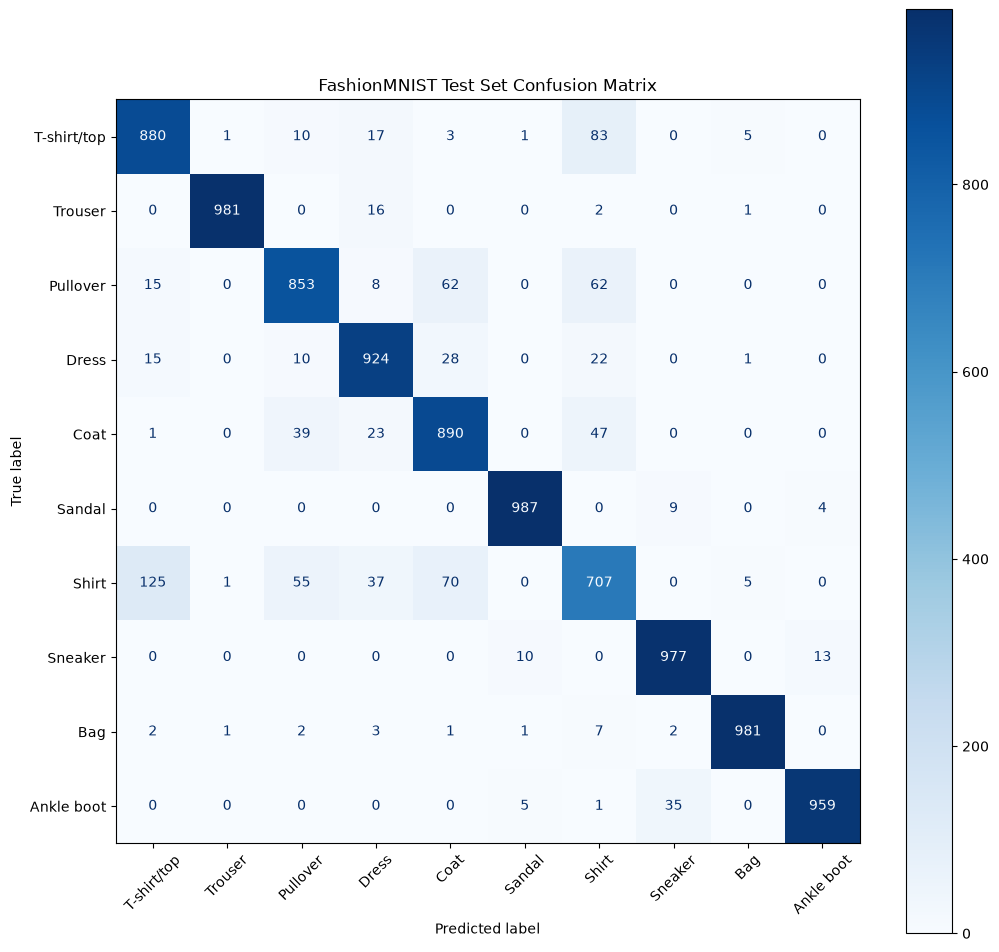

In [22]:
predictions = model.predict(
    x_test,
    verbose=0
)

predicted_labels = np.argmax(
    predictions,
    axis=1
)

cm = confusion_matrix(
    y_test,
    predicted_labels
)

fig, ax = plt.subplots(
    figsize=(12, 12)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues"
)

plt.title(
    "FashionMNIST Test Set Confusion Matrix"
)

plt.show()

In [23]:
expected_classes = {

    "tshirt.jpg":
        "T-shirt/top",

    "trouser.jpg":
        "Trouser",

    "pullover.jpg":
        "Pullover",

    "dress.jpg":
        "Dress",

    "coat.jpg":
        "Coat",

    "sandal.jpg":
        "Sandal",

    "shirt.jpg":
        "Shirt",

    "sneaker.jpg":
        "Sneaker",

    "bag.jpg":
        "Bag",

    "ankle_boot.jpg":
        "Ankle boot"
}

In [24]:
custom_transform_description = """
Resize: 28 x 28
Grayscale: 1 channel
Pixel scaling: /255
Normalization: mean=0.2860, std=0.3530
"""

print(custom_transform_description)


Resize: 28 x 28
Grayscale: 1 channel
Pixel scaling: /255
Normalization: mean=0.2860, std=0.3530



In [25]:
def predict_custom_image(
    image_path,
    model
):

    image = Image.open(
        image_path
    ).convert("L")

    image = image.resize(
        (28, 28)
    )

    image_array = np.array(
        image
    ).astype("float32")

    image_array = (
        image_array / 255.0
    )

    image_array = (
        image_array - mean
    ) / std

    image_array = np.expand_dims(
        image_array,
        axis=-1
    )

    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    probabilities = model.predict(
        image_array,
        verbose=0
    )[0]

    predicted_index = np.argmax(
        probabilities
    )

    confidence = probabilities[
        predicted_index
    ]

    return (
        predicted_index,
        confidence
    )

In [26]:
results = []

for filename in custom_images:

    image_path = os.path.join(
        DATASET_DIR,
        filename
    )

    predicted_index, confidence = (
        predict_custom_image(
            image_path,
            model
        )
    )

    predicted_class = class_names[
        predicted_index
    ]

    expected_class = expected_classes.get(
        filename,
        "Unknown"
    )

    results.append({

        "filename": filename,

        "predicted":
            predicted_class,

        "expected":
            expected_class,

        "confidence":
            confidence
    })


for result in results:

    print(
        f"{result['filename']} | "
        f"True: {result['expected']} | "
        f"Pred: {result['predicted']} | "
        f"Confidence: "
        f"{result['confidence'] * 100:.2f}%"
    )

ankle_boot.jpg | True: Ankle boot | Pred: Bag | Confidence: 92.48%
bag.jpg | True: Bag | Pred: Bag | Confidence: 99.77%
coat.jpg | True: Coat | Pred: Bag | Confidence: 90.82%
dress.jpg | True: Dress | Pred: Bag | Confidence: 91.32%
pullover.jpg | True: Pullover | Pred: Pullover | Confidence: 56.63%
sandal.jpg | True: Sandal | Pred: Bag | Confidence: 99.47%
shirt.jpg | True: Shirt | Pred: Bag | Confidence: 53.90%
sneaker.jpg | True: Sneaker | Pred: Bag | Confidence: 88.88%
trouser.jpg | True: Trouser | Pred: Bag | Confidence: 98.94%
tshirt.jpg | True: T-shirt/top | Pred: Bag | Confidence: 95.52%


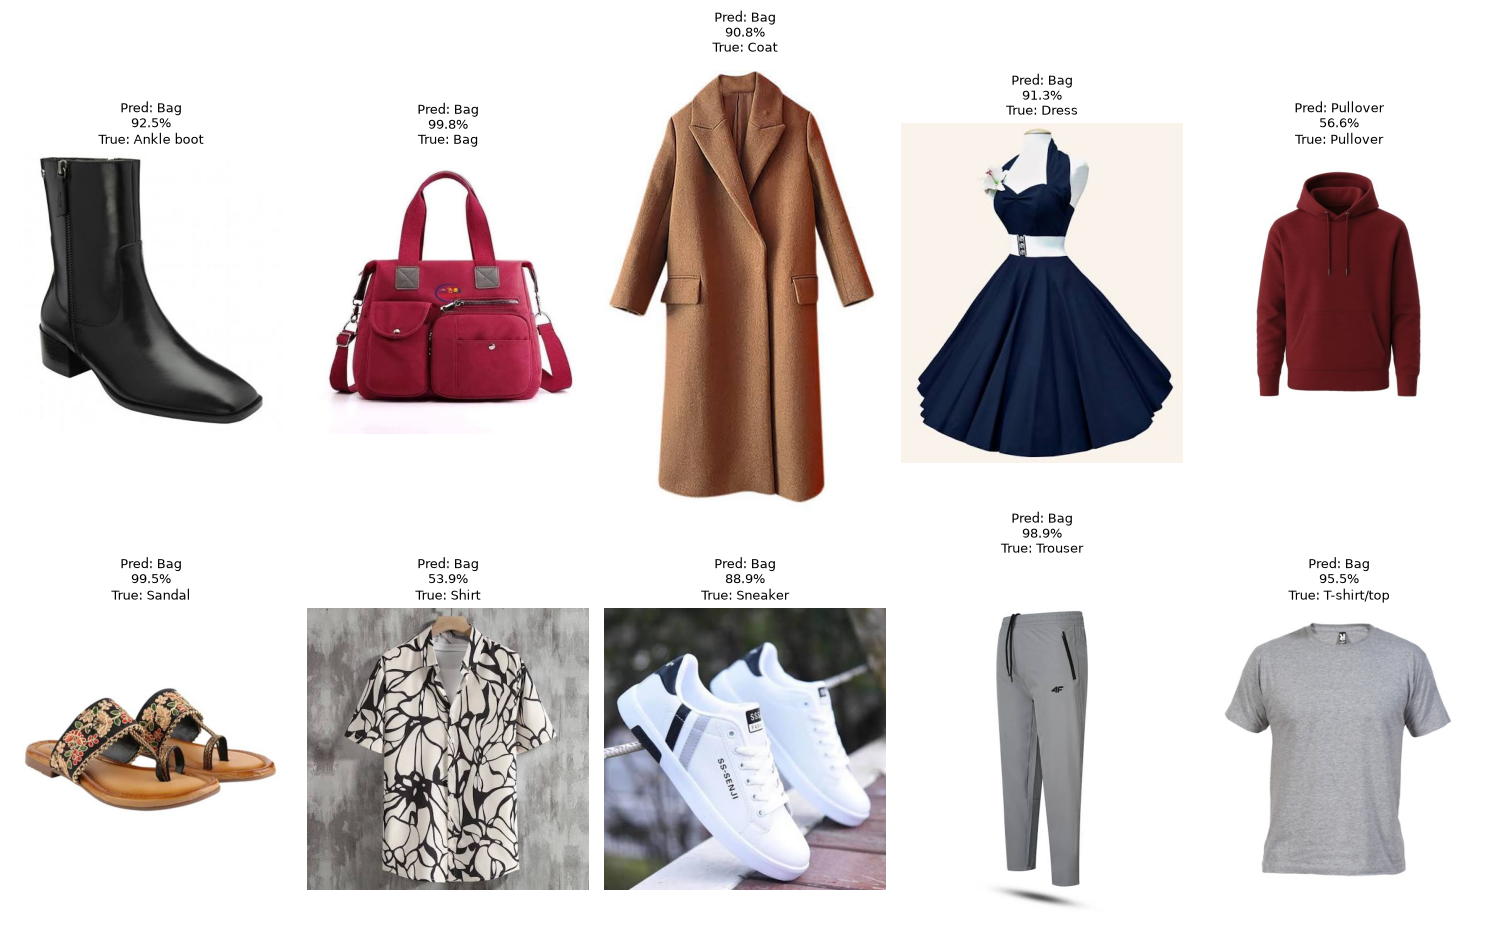

In [27]:
plt.figure(figsize=(15, 10))

for i, result in enumerate(results):

    image_path = os.path.join(
        DATASET_DIR,
        result["filename"]
    )

    image = Image.open(
        image_path
    ).convert("RGB")

    plt.subplot(2, 5, i + 1)

    plt.imshow(image)

    plt.title(
        f"Pred: {result['predicted']}\n"
        f"{result['confidence'] * 100:.1f}%\n"
        f"True: {result['expected']}",
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [28]:
correct = 0

for result in results:

    if (
        result["predicted"]
        == result["expected"]
    ):

        correct += 1


custom_accuracy = (
    correct / len(results)
)

print(
    f"Custom Image Accuracy: "
    f"{custom_accuracy * 100:.2f}%"
)

print(
    f"Correct: "
    f"{correct}/{len(results)}"
)

Custom Image Accuracy: 20.00%
Correct: 2/10


In [29]:
incorrect_indices = np.where(
    predicted_labels != y_test
)[0]

print(
    "Incorrect test images:",
    len(incorrect_indices)
)

Incorrect test images: 861


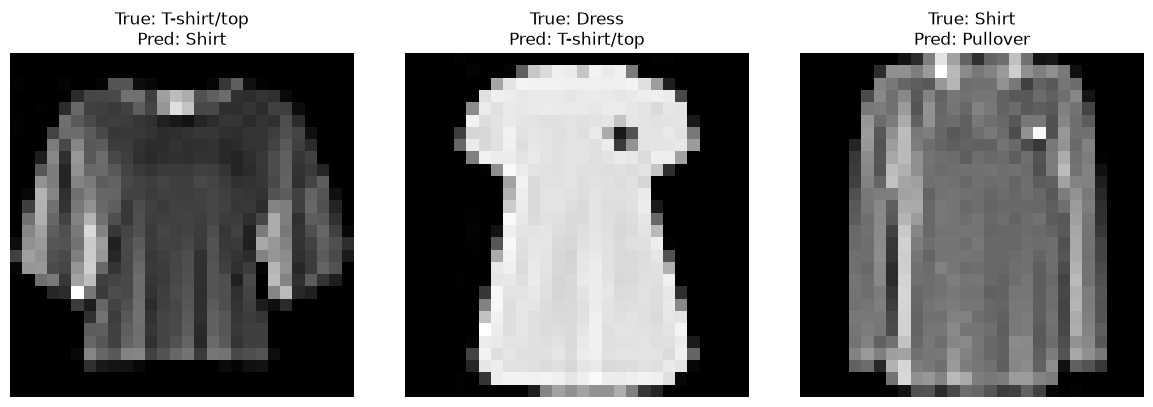

In [30]:
random_error_indices = np.random.choice(
    incorrect_indices,
    size=3,
    replace=False
)

plt.figure(figsize=(12, 4))

for i, index in enumerate(
    random_error_indices
):

    image = (
        x_test[index] * std
    ) + mean

    plt.subplot(1, 3, i + 1)

    plt.imshow(
        image.squeeze(),
        cmap="gray"
    )

    plt.title(
        f"True: "
        f"{class_names[y_test[index]]}\n"
        f"Pred: "
        f"{class_names[predicted_labels[index]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [31]:
print("=" * 60)
print("FINAL PROJECT RESULTS")
print("=" * 60)

print(
    f"Standard Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

print(
    f"Custom Image Accuracy: "
    f"{custom_accuracy * 100:.2f}%"
)

print(
    f"Number of Custom Images: "
    f"{len(results)}"
)

print(
    f"Model Path: "
    f"{MODEL_PATH}"
)

print("=" * 60)

FINAL PROJECT RESULTS
Standard Test Accuracy: 91.39%
Custom Image Accuracy: 20.00%
Number of Custom Images: 10
Model Path: e:\sabbir_vai\AI_ML_Final_Project\model\fashion_mnist_cnn.keras
